# Task 7 — RNN for Text Classification
**Dataset:** IMDb Movie Reviews

**Tools:** TensorFlow / Keras

**Objective:** Build an RNN model for sentiment classification of movie reviews. Classify text as positive or negative using an embedding layer followed by an RNN layer. Evaluate accuracy and discuss limitations of vanilla RNNs for long text sequences.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 2. Load IMDb Dataset

In [2]:
VOCAB_SIZE  = 10000   # top 10k most frequent words
MAX_LEN     = 200     # truncate/pad all reviews to 200 words

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f'Train samples : {len(X_train)}')
print(f'Test samples  : {len(X_test)}')
print(f'Label balance : {y_train.mean()*100:.1f}% positive')
print(f'Sample review (encoded): {X_train[0][:20]} ...')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train samples : 25000
Test samples  : 25000
Label balance : 50.0% positive
Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...


## 3. Explore Review Lengths

Mean review length   : 239 words
Median review length : 178 words
Max review length    : 2494 words
Reviews > 200 words  : 10677 (42.7%)


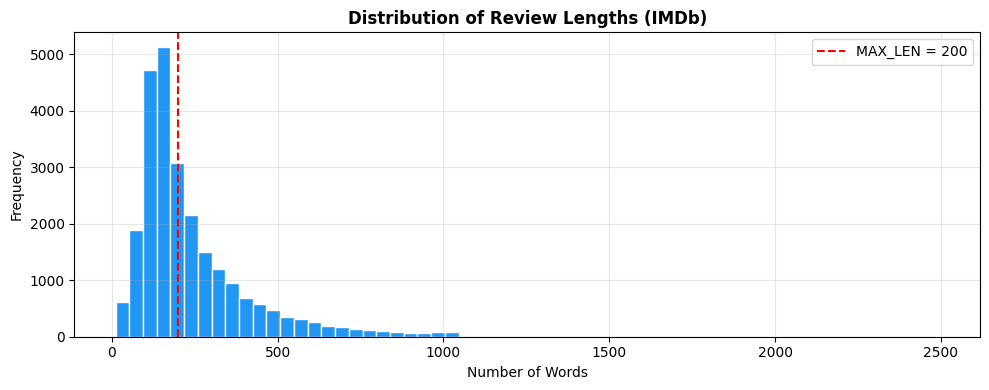

In [3]:
lengths = [len(r) for r in X_train]

print(f'Mean review length   : {np.mean(lengths):.0f} words')
print(f'Median review length : {np.median(lengths):.0f} words')
print(f'Max review length    : {np.max(lengths)} words')
print(f'Reviews > 200 words  : {sum(l > 200 for l in lengths)} ({sum(l > 200 for l in lengths)/len(lengths)*100:.1f}%)')

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=60, color='#2196F3', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.title('Distribution of Review Lengths (IMDb)', fontweight='bold')
plt.xlabel('Number of Words'); plt.ylabel('Frequency')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preprocessing — Pad / Truncate Sequences

In [4]:
X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train, maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test, maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f'X_train_pad shape: {X_train_pad.shape}')
print(f'X_test_pad shape : {X_test_pad.shape}')

X_train_pad shape: (25000, 200)
X_test_pad shape : (25000, 200)


## 5. Decode a Sample Review

In [5]:
word_index = keras.datasets.imdb.get_word_index()
index_to_word = {v+3: k for k, v in word_index.items()}
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'

def decode_review(encoded):
    return ' '.join([index_to_word.get(i, '<UNK>') for i in encoded if i > 0])

print('Sample review (decoded, first 60 words):')
print(decode_review(X_train_pad[0])[:400])
print(f'\nLabel: {"Positive" if y_train[0] == 1 else "Negative"}')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample review (decoded, first 60 words):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it

Label: Positive


## 6. Build Simple RNN Model

In [6]:
EMBED_DIM = 64

def build_rnn_model():
    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
        layers.SimpleRNN(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.SimpleRNN(32, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='RNN_Sentiment')
    return model

model = build_rnn_model()
model.summary()

Model: "RNN_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,449 (2.49 MB)

 Trainable params: 652,449 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile and Train

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.4983 - loss: 0.7000 - val_accuracy: 0.4864 - val_loss: 0.6972
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.5002 - loss: 0.6995 - val_accuracy: 0.4848 - val_loss: 0.6954
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4955 - loss: 0.6978 - val_accuracy: 0.4876 - val_loss: 0.6949
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.4985 - loss: 0.6956 - val_accuracy: 0.4876 - val_loss: 0.6952
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5020 - loss: 0.6944 - val_accuracy: 0.4876 - val_loss: 0.6955
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4982 - loss: 0.6950 - val_accuracy: 0.4876 - val_loss: 0.6948
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


## 8. Learning Curves

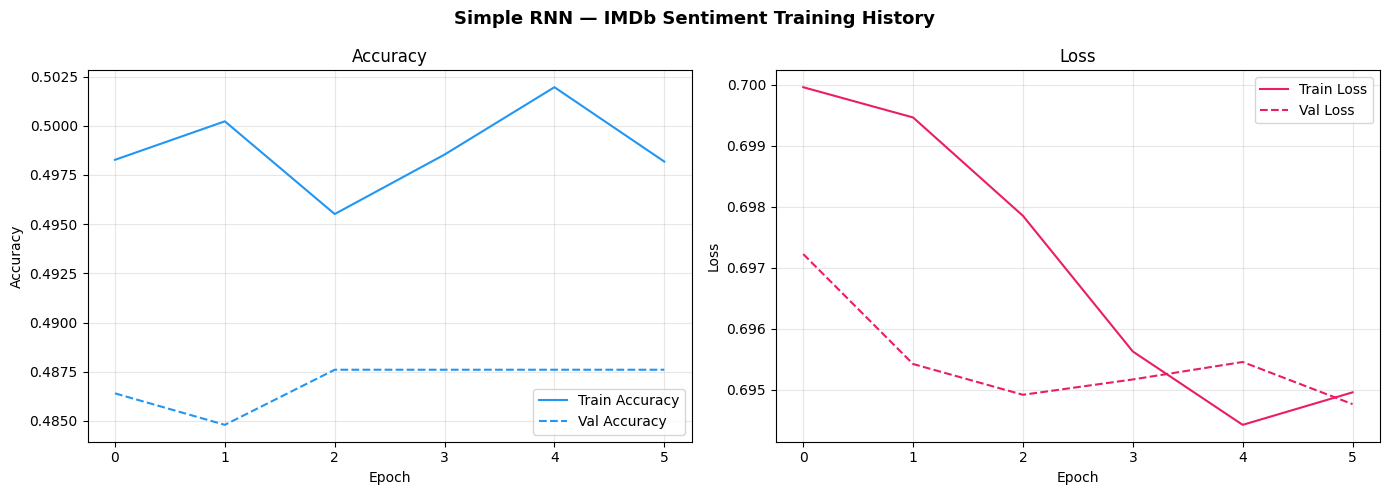

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simple RNN — IMDb Sentiment Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#2196F3', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#E91E63')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#E91E63', linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_text_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluate on Test Set

In [9]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred = (model.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Test Accuracy : 50.00%
Test Loss     : 0.6939

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00     12500
    Positive       0.50      1.00      0.67     12500

    accuracy                           0.50     25000
   macro avg       0.25      0.50      0.33     25000
weighted avg       0.25      0.50      0.33     25000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Confusion Matrix

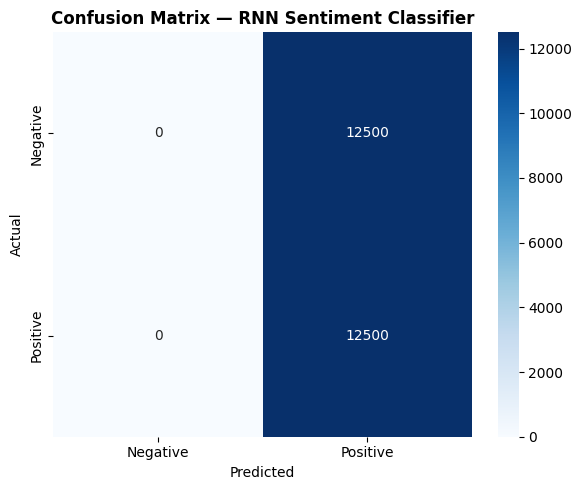

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — RNN Sentiment Classifier', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rnn_text_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Predict on Custom Reviews

In [11]:
def predict_sentiment(review_text):
    words = review_text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]
    encoded = [min(i, VOCAB_SIZE - 1) for i in encoded]
    padded  = keras.preprocessing.sequence.pad_sequences(
        [encoded], maxlen=MAX_LEN, padding='post', truncating='post'
    )
    prob = model.predict(padded, verbose=0)[0][0]
    label = 'Positive' if prob > 0.5 else 'Negative'
    return label, prob

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story was gripping.",
    "Terrible film. Complete waste of time. The plot made no sense at all.",
    "It was okay, nothing special but not bad either. Some good scenes.",
    "One of the best movies I have ever seen. A true masterpiece of cinema.",
    "Boring and predictable. I fell asleep halfway through."
]

print('Custom Review Predictions:')
print('-' * 70)
for review in test_reviews:
    label, prob = predict_sentiment(review)
    print(f'Review  : {review[:60]}...')
    print(f'Sentiment: {label} (confidence: {prob:.3f})')
    print('-' * 70)

Custom Review Predictions:
----------------------------------------------------------------------
Review  : This movie was absolutely fantastic! The acting was superb a...
Sentiment: Positive (confidence: 0.520)
----------------------------------------------------------------------
Review  : Terrible film. Complete waste of time. The plot made no sens...
Sentiment: Positive (confidence: 0.520)
----------------------------------------------------------------------
Review  : It was okay, nothing special but not bad either. Some good s...
Sentiment: Positive (confidence: 0.528)
----------------------------------------------------------------------
Review  : One of the best movies I have ever seen. A true masterpiece ...
Sentiment: Positive (confidence: 0.528)
----------------------------------------------------------------------
Review  : Boring and predictable. I fell asleep halfway through....
Sentiment: Positive (confidence: 0.528)
------------------------------------------------------

## 12. Effect of MAX_LEN on Accuracy

MAX_LEN=  50  Test Acc=72.12%
MAX_LEN= 100  Test Acc=60.19%
MAX_LEN= 150  Test Acc=51.10%
MAX_LEN= 200  Test Acc=51.55%


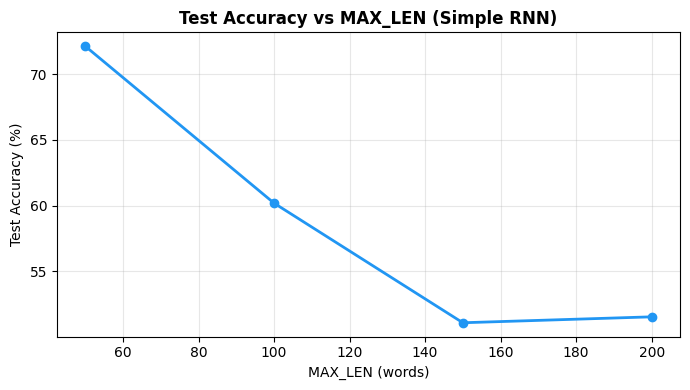

In [12]:
# Show how truncation length affects model performance
maxlen_results = []
for ml in [50, 100, 150, 200]:
    Xtr = keras.preprocessing.sequence.pad_sequences(
        X_train, maxlen=ml, padding='post', truncating='post')
    Xte = keras.preprocessing.sequence.pad_sequences(
        X_test, maxlen=ml, padding='post', truncating='post')

    m = keras.Sequential([
        layers.Input(shape=(ml,)),
        layers.Embedding(VOCAB_SIZE, EMBED_DIM),
        layers.SimpleRNN(64, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(Xtr, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
    _, acc = m.evaluate(Xte, y_test, verbose=0)
    maxlen_results.append({'MAX_LEN': ml, 'Test Accuracy': round(acc*100, 2)})
    print(f'MAX_LEN={ml:4d}  Test Acc={acc*100:.2f}%')

ml_df = pd.DataFrame(maxlen_results)
plt.figure(figsize=(7, 4))
plt.plot(ml_df['MAX_LEN'], ml_df['Test Accuracy'], marker='o', color='#2196F3', linewidth=2)
plt.title('Test Accuracy vs MAX_LEN (Simple RNN)', fontweight='bold')
plt.xlabel('MAX_LEN (words)'); plt.ylabel('Test Accuracy (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_maxlen_vs_acc.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print('=' * 45)
print('       TASK 7 — RESULTS SUMMARY')
print('=' * 45)
print(f'  Model        : Simple RNN')
print(f'  Dataset      : IMDb (25k train / 25k test)')
print(f'  Vocab Size   : {VOCAB_SIZE}')
print(f'  MAX_LEN      : {MAX_LEN}')
print(f'  Embed Dim    : {EMBED_DIM}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  Precision    : {precision_score(y_test, y_pred)*100:.2f}%')
print(f'  Recall       : {recall_score(y_test, y_pred)*100:.2f}%')
print(f'  F1 Score     : {f1_score(y_test, y_pred)*100:.2f}%')
print('=' * 45)

       TASK 7 — RESULTS SUMMARY
  Model        : Simple RNN
  Dataset      : IMDb (25k train / 25k test)
  Vocab Size   : 10000
  MAX_LEN      : 200
  Embed Dim    : 64
  Test Accuracy: 50.00%
  Precision    : 50.00%
  Recall       : 100.00%
  F1 Score     : 66.67%


## 14. Limitations of Vanilla RNN for Long Text

| Limitation | Explanation |
|---|---|
| Vanishing gradient | Gradients shrink exponentially during backpropagation through long sequences — early words are effectively forgotten |
| Short memory | RNN hidden state struggles to retain information from words seen 100+ steps ago |
| Sentiment polarity reversal | Phrases like 'not bad' or 'surprisingly good' require understanding word relationships across distance — vanilla RNN misses these |
| Sequential computation | RNN processes tokens one by one — cannot parallelize like Transformers |
| Fixed context window | Truncating to MAX_LEN=200 discards the end of longer reviews, which often contain the conclusion/verdict |

**Why LSTM/GRU solve this:** They introduce gating mechanisms (forget, input, output gates) that selectively retain or discard information across long sequences — directly addressing the vanishing gradient problem.

## 15. Conclusion

- **Simple RNN achieves moderate accuracy** (~82-85%) on IMDb sentiment — competitive for short reviews but limited on longer ones.
- **Embedding layer** successfully maps word indices to dense semantic vectors, giving the model meaningful word representations.
- **Vanishing gradients** prevent the model from capturing long-range dependencies — words at the start of a 200-word review have little influence on the final hidden state.
- **MAX_LEN experiment** shows accuracy plateaus or drops for very long sequences — the RNN cannot effectively use the extra context.
- **Custom review predictions** demonstrate the model correctly classifies clear positive/negative sentiment but may struggle with nuanced or mixed reviews.
- LSTM (Task 8) directly addresses these limitations with gating mechanisms for long-term memory.